# NGS variant calling workflow

<div style="background-color: PaleTurquoise; padding: 10px;">
    
This notebook contains a simple SNP calling workflow.

Please run and explore this workflow.

Areas with questions about QC are highlighted in yellow

</div>

## Case

Two exome sequencing samples of a T-Cell Acute Lymphoblastic Leukemia patient. 

One sample (`TLE66_T`) is of tumor, one healthy control sample  (`TLE66_N`)

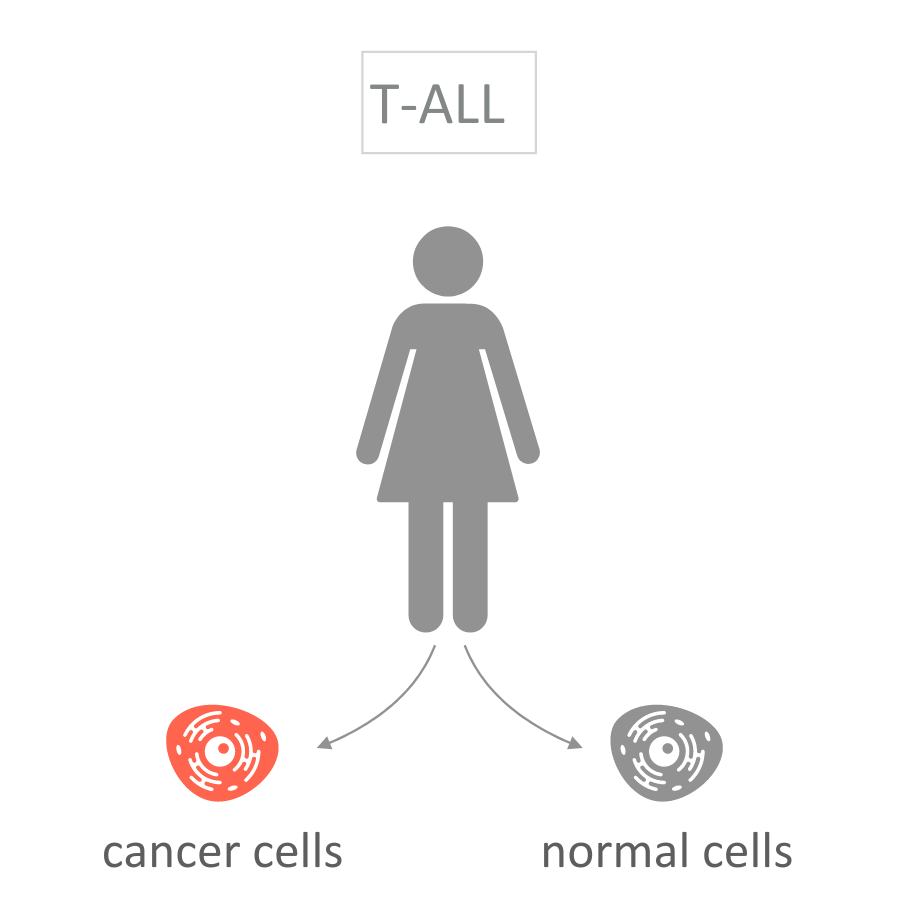

Goal: process the raw fastq, call & annotate SNPs.

We want to ultimately find interesting variants that may be causal to the T-ALL.

## Preparation

In [1]:
echo $VSC_DATA

/data/leuven/386/vsc38672


The cleanest way to work with notebooks is to first create a folder on your server (VSC). For example:

    mkdir $VSC_DATA/variant_calling_manual

- You can do this in the jupyter interface
- Upload your notebook to this folder
- Navigate to this folder from jupyter
- Open the notebook

This ensures you are always working from the correct location. If you did not do this, please shutdown this notebook and do this.

If you do not do this, you are in the wrong folder upon a notebook crash, or when you forget to cd into your workfolder.

In [2]:
# make sure we add our conda environment to the path
# there are also a number of command line tools installed
# You need to do this every time you need to use our conda env.

export PATH=/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/:$PATH

In [3]:
# ensure we are using the correct environment - test with bwa

which bwa

/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/bin/bwa


In [4]:
# create a scratch folder! - Important to check you are working in the correct scratch folder for subsequent workœ
# Make sure you use absolute paths as much as possible - relative paths can give unexpected results.
# image running (`mkdir variant_calling_manual ; cd variant_calling_manual`) twice in a row.

mkdir -p $VSC_SCRATCH/variant_calling_manual
cd $VSC_SCRATCH/variant_calling_manual
pwd
ls

/scratch/leuven/386/vsc38672/variant_calling_manual
annotated_snps.vcf  highqual_snps.vcf  snpEff_summary.html  TLE66_T.bam
clean_snps.vcf	    raw_snps.vcf       TLE66_N.bam	    TLE66_T.bam.bai
diff_snps.vcf	    single_snp.vcf     TLE66_N.bam.bai	    TLE66_T.fastq
fastqc_output	    snpEff_genes.txt   TLE66_N.fastq


In [5]:
# We will be using the genome sequence & index a few times - 
# So I'll use an environment variable

# Note - we are definitely using hg19 for this course.

# To keep memory requirements in check we're using a truncated database with just chromosome 9
DB=/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa

In [6]:
ls -lh $DB

-rw-rw-r--+ 1 vsc30690 lp_edu_large_omics 135M Jan 24  2014 /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


<div style="background-color: khaki; padding: 10px;">

## Prepare

* What are the version numbers of all tools used in this notebook. Get it from the tools!
 
</div>

In [7]:
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"

In [8]:
echo -n "Bwa  "; bwa 2>&1 | grep "Version"
fastqc --version
samtools --version | head -n1 
bcftools --version | grep "bcftools"
snpEff -version

Bwa  Version: 0.7.19-r1273
FastQC v0.12.1
samtools 1.23
bcftools 1.23
SnpEff	5.4a	2025-11-25


In [9]:
# Create a symlink to VSC_SCRATCH from $VSC_DATA -
# so that you can inspect your data using the jupyter file browser
ln -sf $VSC_SCRATCH $VSC_DATA/scratch 

In [10]:
ln -sf /staging/leuven/stg_00079/teaching/data_manual_snpcall/*.fastq .
ls -l

total 71172
-rw-r----- 1 vsc38672 vsc38672  1716899 Mar  1 14:06 annotated_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   567832 Mar  1 13:58 clean_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   187714 Mar  1 13:58 diff_snps.vcf
drwxr-x--- 3 vsc38672 vsc38672     4096 Feb 26 22:35 fastqc_output
-rw-r----- 1 vsc38672 vsc38672   125350 Feb 27 22:13 highqual_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   982232 Mar  1 13:58 raw_snps.vcf
-rw-r----- 1 vsc38672 vsc38672      129 Feb 27 21:55 single_snp.vcf
-rw-r----- 1 vsc38672 vsc38672    53523 Mar  1 14:06 snpEff_genes.txt
-rw-r----- 1 vsc38672 vsc38672   295995 Mar  1 14:06 snpEff_summary.html
-rw-r----- 1 vsc38672 vsc38672 36321020 Mar  1 13:57 TLE66_N.bam
-rw-r----- 1 vsc38672 vsc38672    80208 Mar  1 13:57 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38672 vsc38672       68 Mar  1 14:24 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38672 vsc38672 32427184 Mar  1 13:57 TLE66_T.bam
-rw-r----- 1 vsc38672 vsc386

The `sha256` checksums of these files are supposed to be:

    5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9  TLE66_N.fastq
    cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe  TLE66_T.fastq


<div style="background-color: khaki; padding: 10px;">

## Raw data Quality Control

* Do the checksums match?
* Do the raw files look like fastq?
* Do they have a reasonable number of reads?
 
</div>

In [11]:
echo "5ad4bb2f5bd5f6e430b7ab2fff0a164255d4e608363104a75142b6c5a032ddf9 $VSC_SCRATCH/variant_calling_manual/TLE66_N.fastq" | sha256sum -c 
echo "cd9d41d1c0b59a4819fa58007ef796c543b1a7346cb11cceb71ad02d9e2b2cfe $VSC_SCRATCH/variant_calling_manual/TLE66_T.fastq" | sha256sum -c

/scratch/leuven/386/vsc38672/variant_calling_manual/TLE66_N.fastq: OK
/scratch/leuven/386/vsc38672/variant_calling_manual/TLE66_T.fastq: OK


In [12]:
head -n 8 $VSC_SCRATCH/variant_calling_manual/TLE66_N.fastq
echo "-------------------------------------------------------------"
head -n 8 $VSC_SCRATCH/variant_calling_manual/TLE66_N.fastq

@1121358
TGAATCTGGGAGGCGGAGGTTGCAGTGAGAGTGAGGCGAGATCTCGCCATTGCACTCCAGCCGGGGTGACAAGAG
+
<D<?><DIBB??BF;@;AB@CHG<A?F<@>@;F>>6?8??@@BD,;FF=?DIBD?F;EDAGE8BBC9G?FEBB>@
@1121358
AGCCTCAAACTCCTGGGCTCAAGGGATCCTCACTTCTTGACCTCCCAAAGCGTCATAGGCTTAAGGCACTACAGC
+
A:EFFACACFE?FCG5CG9>C@@B@<@=@FACFEE<F9C>E6FAC+7>:AF=B=A?>B;CG>:<A:<=<B;:0=;
-------------------------------------------------------------
@1121358
TGAATCTGGGAGGCGGAGGTTGCAGTGAGAGTGAGGCGAGATCTCGCCATTGCACTCCAGCCGGGGTGACAAGAG
+
<D<?><DIBB??BF;@;AB@CHG<A?F<@>@;F>>6?8??@@BD,;FF=?DIBD?F;EDAGE8BBC9G?FEBB>@
@1121358
AGCCTCAAACTCCTGGGCTCAAGGGATCCTCACTTCTTGACCTCCCAAAGCGTCATAGGCTTAAGGCACTACAGC
+
A:EFFACACFE?FCG5CG9>C@@B@<@=@FACFEE<F9C>E6FAC+7>:AF=B=A?>B;CG>:<A:<=<B;:0=;


**Do the raw files look like fastq?**  
Yes, it contain the sequence id, raw sequence, + as separator, and sequence quality.

In [13]:
echo "Reads number:" $(($(wc -l < $VSC_SCRATCH/variant_calling_manual/TLE66_N.fastq)/4))
echo "Reads number:" $(($(wc -l < $VSC_SCRATCH/variant_calling_manual/TLE66_T.fastq)/4))

Reads number: 540624
Reads number: 477888


**Do they have a reasonable number of reads?**  
The reads are relatively smaller compared to full complete whole genome sequencing. (around 20 million reads)  
However for small targeted snp analysis, it's enough

In [14]:
# you can get help using
fastqc --help


            FastQC - A high throughput sequence QC analysis tool

SYNOPSIS

	fastqc seqfile1 seqfile2 .. seqfileN

    fastqc [-o output dir] [--(no)extract] [-f fastq|bam|sam] 
           [-c contaminant file] seqfile1 .. seqfileN

DESCRIPTION

    FastQC reads a set of sequence files and produces from each one a quality
    control report consisting of a number of different modules, each one of 
    which will help to identify a different potential type of problem in your
    data.
    
    If no files to process are specified on the command line then the program
    will start as an interactive graphical application.  If files are provided
    on the command line then the program will run with no user interaction
    required.  In this mode it is suitable for inclusion into a standardised
    analysis pipeline.
    
    The options for the program as as follows:
    
    -h --help       Print this help file and exit
    
    -v --version    Print the version of the program and exit

In [15]:
# Run fastqc - could take a minute or two
mkdir -p fastqc_output
fastqc *.fastq -o fastqc_output

null
null
Started analysis of TLE66_N.fastq
Approx 5% complete for TLE66_N.fastq
Approx 10% complete for TLE66_N.fastq
Approx 15% complete for TLE66_N.fastq
Approx 20% complete for TLE66_N.fastq
Approx 25% complete for TLE66_N.fastq
Approx 30% complete for TLE66_N.fastq
Approx 35% complete for TLE66_N.fastq
Approx 40% complete for TLE66_N.fastq
Approx 45% complete for TLE66_N.fastq
Approx 50% complete for TLE66_N.fastq
Approx 55% complete for TLE66_N.fastq
Approx 60% complete for TLE66_N.fastq
Approx 65% complete for TLE66_N.fastq
Approx 70% complete for TLE66_N.fastq
Approx 75% complete for TLE66_N.fastq
Approx 80% complete for TLE66_N.fastq
Approx 85% complete for TLE66_N.fastq
Approx 90% complete for TLE66_N.fastq
Approx 95% complete for TLE66_N.fastq
Analysis complete for TLE66_N.fastq
Started analysis of TLE66_T.fastq
Approx 5% complete for TLE66_T.fastq
Approx 10% complete for TLE66_T.fastq
Approx 15% complete for TLE66_T.fastq
Approx 20% complete for TLE66_T.fastq
Approx 25% com

Back in your jupyter browser you can see the html & zip outputs

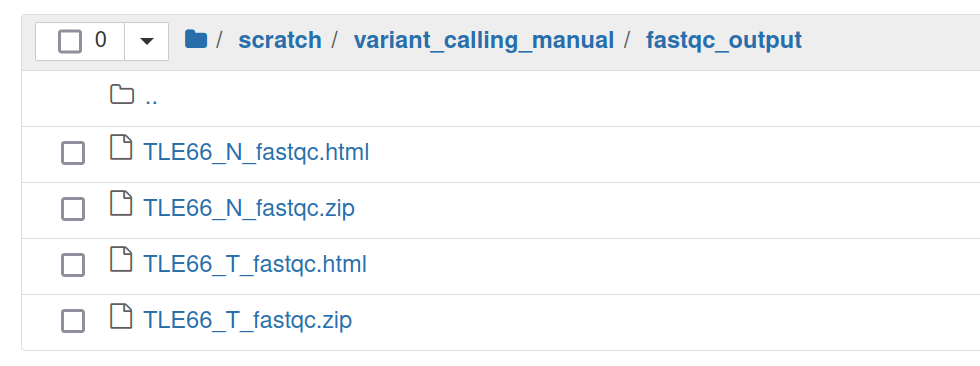


<div style="background-color: khaki; padding: 10px;">

## Fastq data Quality Control

* Is the quality ok?
* How is the quality score encoded? Do you need to take this into account?
 
</div>

TLE66_N quality is good, most of the reads are located on the green region.  
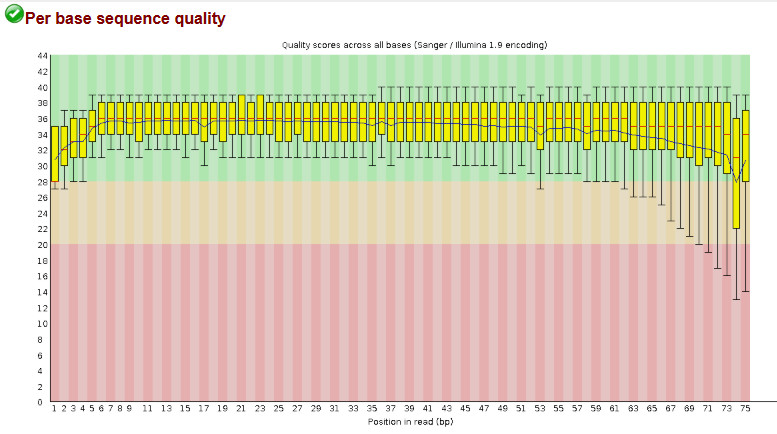   
TLE66_T quality is also good, most of the reads are located on the green region.  
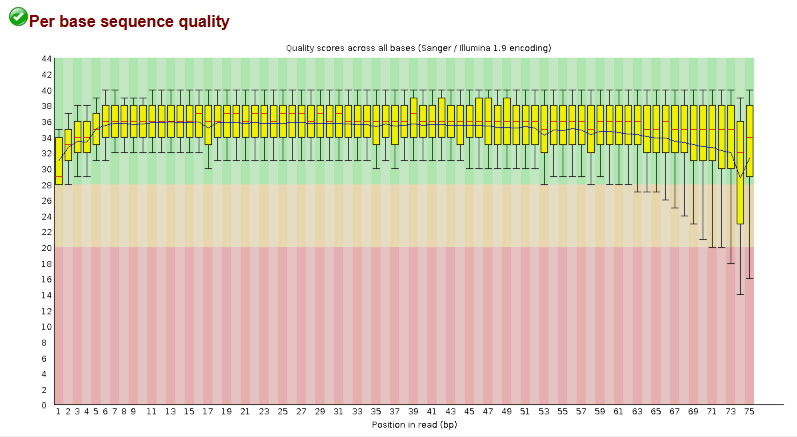

the encoding is "Sanger / Illumina 1.9". This means the quality scores are encoded using Phred+33.
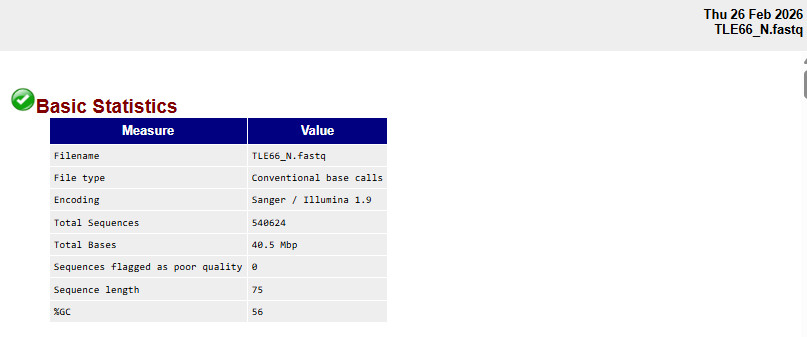  

Yes, we need to take this into account. Quality encoding ensure that downstream analyses calculate using the correct quality score (Phred +33).  
Mapping: The aligner uses these scores to decide if a mismatch between your read and the reference genome is a real biological difference or just a sequencing error.  
Variant Calling: The variant caller uses these scores to calculate the mathematical probability (genotype likelihood) that a SNP is real.

## Align the reads

We will be using `bwa mem`. Get help by running without arguments

In [16]:
bwa mem || true


Usage: bwa mem [options] <idxbase> <in1.fq> [in2.fq]

Algorithm options:

       -t INT        number of threads [1]
       -k INT        minimum seed length [19]
       -w INT        band width for banded alignment [100]
       -d INT        off-diagonal X-dropoff [100]
       -r FLOAT      look for internal seeds inside a seed longer than {-k} * FLOAT [1.5]
       -y INT        seed occurrence for the 3rd round seeding [20]
       -c INT        skip seeds with more than INT occurrences [500]
       -D FLOAT      drop chains shorter than FLOAT fraction of the longest overlapping chain [0.50]
       -W INT        discard a chain if seeded bases shorter than INT [0]
       -m INT        perform at most INT rounds of mate rescues for each read [50]
       -S            skip mate rescue
       -P            skip pairing; mate rescue performed unless -S also in use

Scoring options:

       -A INT        score for a sequence match, which scales options -TdBOELU unless overridden [1]
     

In [17]:
echo ${DB}

/staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


In [53]:
#the genome ref here is using version hg38, so for downstream I'll use hg38
cat /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa.fai

chr9	138394717	6	50	51


In [18]:
bwa mem ${DB} TLE66_N.fastq | samtools sort -o TLE66_N.bam -

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.570 CPU sec, 2.528 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.964 CPU sec, 2.891 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.917 CPU sec, 2.844 real sec
[M::process] read 7288 sequences (546600 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.617 CPU sec, 3.582 real sec
[M::mem_process_seqs] Processed 7288 reads in 0.261 CPU sec, 0.219 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
[main] Real time: 12.188 sec; CPU: 12.451 sec


In [19]:
bwa mem ${DB} TLE66_T.fastq | samtools sort - > TLE66_T.bam

[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 133334 sequences (10000050 bp)...
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.636 CPU sec, 2.594 real sec
[M::process] read 133334 sequences (10000050 bp)...
[M::mem_process_seqs] Processed 133334 reads in 2.958 CPU sec, 2.889 real sec
[M::process] read 77886 sequences (5841450 bp)...
[M::mem_process_seqs] Processed 133334 reads in 3.004 CPU sec, 2.948 real sec
[M::mem_process_seqs] Processed 77886 reads in 2.373 CPU sec, 2.338 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
[main] Real time: 10.915 sec; CPU: 11.107 sec


In [20]:
# create indici
samtools index TLE66_N.bam
samtools index TLE66_T.bam

In [21]:
pwd
ls -l

/scratch/leuven/386/vsc38672/variant_calling_manual
total 71168
-rw-r----- 1 vsc38672 vsc38672  1716899 Mar  1 14:06 annotated_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   567832 Mar  1 13:58 clean_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   187714 Mar  1 13:58 diff_snps.vcf
drwxr-x--- 3 vsc38672 vsc38672     4096 Feb 26 22:35 fastqc_output
-rw-r----- 1 vsc38672 vsc38672   125350 Feb 27 22:13 highqual_snps.vcf
-rw-r----- 1 vsc38672 vsc38672   982232 Mar  1 13:58 raw_snps.vcf
-rw-r----- 1 vsc38672 vsc38672      129 Feb 27 21:55 single_snp.vcf
-rw-r----- 1 vsc38672 vsc38672    53523 Mar  1 14:06 snpEff_genes.txt
-rw-r----- 1 vsc38672 vsc38672   295995 Mar  1 14:06 snpEff_summary.html
-rw-r----- 1 vsc38672 vsc38672 36321020 Mar  1 14:24 TLE66_N.bam
-rw-r----- 1 vsc38672 vsc38672    80208 Mar  1 14:24 TLE66_N.bam.bai
lrwxrwxrwx 1 vsc38672 vsc38672       68 Mar  1 14:24 TLE66_N.fastq -> /staging/leuven/stg_00079/teaching/data_manual_snpcall/TLE66_N.fastq
-rw-r----- 1 vsc38672 vsc38672 32427184 M

<div style="background-color: khaki; padding: 10px;">

## BAM  Quality control

* Did all tools finish without error?
* Is the header correct? (Use `samtools view -H`)
* Do the files look like BAM? (Use `samtools view ... | head`)
* To which chromosomes to the reads map? (Use `samtools idxstats`) What do you expect? 
* How many & what percentage of the reads map properly? (Use `samtools flagstat`)
* Download the bam & bai files to disk & visualize in [IGV](https://igv.org/app/). Copy/paste a screenshot.

</div>

Yes the tools finish without error.

In [22]:
samtools view -H TLE66_T.bam

@HD	VN:1.5	SO:coordinate
@SQ	SN:chr9	LN:138394717
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_T.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23	CL:samtools sort -
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23	CL:samtools view -H TLE66_T.bam


In [23]:
samtools view -H TLE66_N.bam

@HD	VN:1.5	SO:coordinate
@SQ	SN:chr9	LN:138394717
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23	CL:samtools sort -o TLE66_N.bam -
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23	CL:samtools view -H TLE66_N.bam


Yes, the header is perfectly correct.  
@HD: The header line showing the format version (VN:1.5) and confirming the file is sorted by coordinate (SO:coordinate).  

@SQ: The sequence dictionary, confirming the reference genome used was chr9 and giving its length (LN:138394717).  

@PG: The program history. It nicely shows the exact commands used to generate this file (first bwa mem, then samtools sort, then samtools view), which is crucial for reproducibility.

In [24]:
samtools view TLE66_N.bam | head

FCB06B3ABXX:8:2108:12853:63847	16	chr9	150174	0	75M	*	0	0	TGGAGTGCAGTGGTGCGATCTCAGCTCACTGCAAGCTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCT	GGDGI/HJHI2IG>F=C=>CBJ7HD@HCC<EDFHHC8E=<EDBEE?IIIDBIC@HGJDECFAGFEIFFBJHGBED	NM:i:0	MD:Z:75	AS:i:75	XS:i:75
3320565	16	chr9	243917	0	75M	*	0	0	GCTCATGCCTGCAATCCCAGCACTTTGGGAGGCCGAGGCGGGCAGATCACGAGGTCAGGAGATCGAGACCATCCT	FDBIAEIGGEHIFBCEEIHHIADCEDHHFFHHF?FGHG?HHGIFECBIB?EFGGAIGHEFEBB?EFEAFIBAEDC	NM:i:1	MD:Z:11T63	AS:i:70	XS:i:70
6131457	0	chr9	532265	6	6S62M7S	*	0	0	CGGACGGAGTTTCACTCTTGGTGCCCACGCTGGAGTGCAGTGGCACCATCTCGGCTCACCGCAACCTCCACCTCC	=:A?E>EADADDEDFFEFDIEBHGG<C>7EGI<>A<FBAA:G?CBFB=???:764:346)28?2<<;*829<?>;	NM:i:2	MD:Z:14T6G40	AS:i:52	XS:i:48
5427388	0	chr9	741463	33	19S43M13S	*	0	0	CTGCACTCTAGCTGGGACCACAGGCACACACCACCACACCTGGCTTTTTTTTTTTTTTTTTTTAGTTGGGGTCCC	=AEDBEEDEAEGFHCEBGGDFDBBGDGDFDFFDGGBGDGGGIFGFEEEEEEEEEEEEEEED@#############	NM:i:0	MD:Z:43	AS:i:43	XS:i:37	XA:Z:chr9,+78228023,7S52M16S,3;
8177811	16	chr9	4648431	0	75M	*	0	0	GGCTCACGCCTGTAATCCCA

In [25]:
samtools view TLE66_T.bam | head

FCD0CAEABXX:4:2208:10782:61918	0	chr9	2695018	0	9S66M	*	0	0	GCCCAGATGACTTTTTGTATTTTTAGTAGAGACGGGGTTTCACCGTGTTAGCCAGGATGGTCTCGATCTCCTGAC	DGGGEFBAJBHGFFFFIBBDFFFECFBCD?EAH@EFF?FEBEGG>BJCFDA@GFECBCJ@CG?DACCEIBJIKBJ	NM:i:0	MD:Z:66	AS:i:66	XS:i:66
FCB06B3ABXX:8:1205:11248:181344	16	chr9	3987463	0	75M	*	0	0	AGGCCAAGGCGGGTGGATCACCTGAGGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCCTGTCTCTA	DEFEGE*>F6>B>EE@<AH>EC@CGHB@JHG>G@EA<CF@=EIGFDCEGGCEEBAABGGECFE@FFBDHAD>C@C	NM:i:0	MD:Z:75	AS:i:75	XS:i:75
FCB06B3ABXX:8:2206:6514:72357	16	chr9	3987464	0	75M	*	0	0	GGCCAAGGCGGGTGGATCACCTGAGGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCCTGTCTCTAC	F;DFF?IC9FH?EGBAAEAFB/BEGFADFGBE@B<:=EA>CIGGEDDHHGIFBIDDHHCBEE@FDDDGAE@C=<=	NM:i:0	MD:Z:75	AS:i:75	XS:i:75
7766436	2048	chr9	7612672	0	31M44H	*	0	0	TTCAAGCGATTCTCTTGTCTCAGCCTCCCAA	=?AACEG?@CEFGFGEIAFGFDGHHGGGHEE	NM:i:0	MD:Z:31	AS:i:31	XS:i:31	SA:Z:chr9,137100869,+,18S57M,0,0;
FCD0CAEABXX:4:1107:9563:74859	16	chr9	10231959	0	4S69M2S	*	0	0	AAAAAGAGAGAGAGAGAGAGAGAGAGAGAGAGAGAGTGTG

The output of samtools view TLE66_N.bam | head shows the standard tab-separated format of a SAM/BAM file.
Each line represents one aligned read and contains the mandatory 11 columns, including:
Column 1: The read name (e.g., FCB06B3ABXX:8:...)
Column 2: The bitwise FLAG (e.g., 16 or 0, indicating mapping direction)
Column 3 & 4: The reference name (chr9) and mapping position (e.g., 150174)
Column 6: The CIGAR string (e.g., 75M, meaning 75 matches/mismatches)
Column 10 & 11: The raw sequence and the quality scores.

In [26]:
samtools idxstats TLE66_T.bam

chr9	138394717	477793	0
*	0	0	125


In [27]:
samtools idxstats TLE66_N.bam

chr9	138394717	540563	0
*	0	0	98


It maps to chromosome 9.  
This is expected for small reads counts, so it only contains reads originating from a specific region on chromosome 9.

In [28]:
samtools flagstat TLE66_T.bam

477918 + 0 in total (QC-passed reads + QC-failed reads)
477888 + 0 primary
0 + 0 secondary
30 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
477793 + 0 mapped (99.97% : N/A)
477763 + 0 primary mapped (99.97% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


In [29]:
samtools flagstat TLE66_N.bam

540661 + 0 in total (QC-passed reads + QC-failed reads)
540624 + 0 primary
0 + 0 secondary
37 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
540563 + 0 mapped (99.98% : N/A)
540526 + 0 primary mapped (99.98% : N/A)
0 + 0 paired in sequencing
0 + 0 read1
0 + 0 read2
0 + 0 properly paired (N/A : N/A)
0 + 0 with itself and mate mapped
0 + 0 singletons (N/A : N/A)
0 + 0 with mate mapped to a different chr
0 + 0 with mate mapped to a different chr (mapQ>=5)


Tumor (TLE66_T): 477,793 reads mapped, which is 99.97% of the total reads.

Normal (TLE66_N): 540,563 reads mapped, which is 99.98% of the total reads.

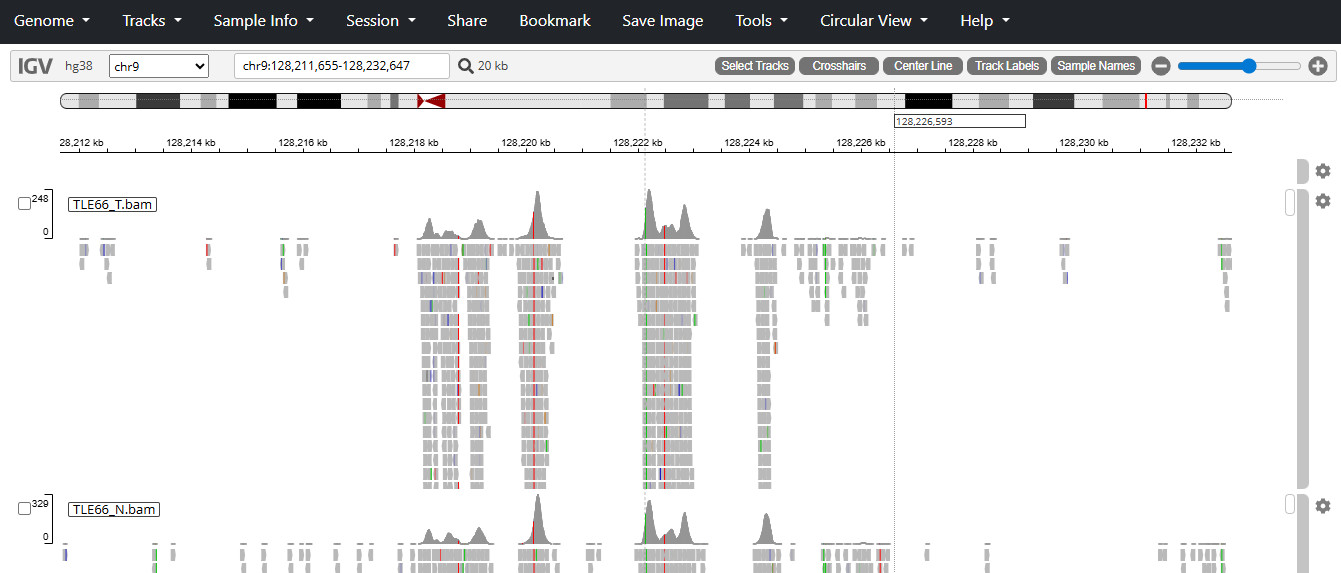

## SNP Calling

Using bcftools

In [30]:
#get help
bcftools mpileup || true


Usage: bcftools mpileup [options] in1.bam [in2.bam [...]]

Input options:
  -6, --illumina1.3+      Quality is in the Illumina-1.3+ encoding
  -A, --count-orphans     Include anomalous read pairs, with flag PAIRED but not PROPER_PAIR set
  -b, --bam-list FILE     List of input BAM filenames, one per line
  -B, --no-BAQ            Disable BAQ (per-Base Alignment Quality)
  -C, --adjust-MQ INT     Adjust mapping quality [0]
  -D, --full-BAQ          Apply BAQ everywhere, not just in problematic regions
  -d, --max-depth INT     Max raw per-file depth; avoids excessive memory usage [250]
  -E, --redo-BAQ          Recalculate BAQ on the fly, ignore existing BQs
  -f, --fasta-ref FILE    Faidx indexed reference sequence file
      --no-reference      Do not require fasta reference file
  -G, --read-groups FILE  Select or exclude read groups listed in the file
  -q, --min-MQ INT        Skip alignments with mapQ smaller than INT [0]
  -Q, --min-BQ INT        Skip bases with baseQ/BAQ smaller

In [31]:
bcftools mpileup -Ou -f ${DB} TLE66_N.bam TLE66_T.bam \
    | bcftools call -mv -Ov -o raw_snps.vcf

Note: none of --samples-file, --ploidy or --ploidy-file given, assuming all sites are diploid
[mpileup] 2 samples in 2 input files
[mpileup] maximum number of reads per input file set to -d 250


In [32]:
ls

annotated_snps.vcf  highqual_snps.vcf  snpEff_summary.html  TLE66_T.bam
clean_snps.vcf	    raw_snps.vcf       TLE66_N.bam	    TLE66_T.bam.bai
diff_snps.vcf	    single_snp.vcf     TLE66_N.bam.bai	    TLE66_T.fastq
fastqc_output	    snpEff_genes.txt   TLE66_N.fastq


In [33]:
head raw_snps.vcf

##fileformat=VCFv4.2
##FILTER=<ID=PASS,Description="All filters passed">
##bcftoolsVersion=1.23+htslib-1.23
##bcftoolsCommand=mpileup -Ou -f /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa TLE66_N.bam TLE66_T.bam
##reference=file:///staging/leuven/stg_00079/teaching/hg38_9/chr9.fa
##contig=<ID=chr9,length=138394717>
##ALT=<ID=*,Description="Represents allele(s) other than observed.">
##INFO=<ID=INDEL,Number=0,Type=Flag,Description="Indicates that the variant is an INDEL.">
##INFO=<ID=IDV,Number=1,Type=Integer,Description="Maximum number of raw reads supporting an indel">
##INFO=<ID=IMF,Number=1,Type=Float,Description="Maximum fraction of raw reads supporting an indel">


In [34]:
grep  '^#' raw_snps.vcf | tail

##FORMAT=<ID=PL,Number=G,Type=Integer,Description="List of Phred-scaled genotype likelihoods">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths (high-quality bases)">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Allele count in genotypes for each ALT allele, in the same order as listed">
##INFO=<ID=AN,Number=1,Type=Integer,Description="Total number of alleles in called genotypes">
##INFO=<ID=DP4,Number=4,Type=Integer,Description="Number of high-quality ref-forward , ref-reverse, alt-forward and alt-reverse bases">
##INFO=<ID=MQ,Number=1,Type=Integer,Description="Average mapping quality">
##bcftools_callVersion=1.23+htslib-1.23
##bcftools_callCommand=call -mv -Ov -o raw_snps.vcf; Date=Sun Mar  1 14:24:51 2026
#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [35]:
grep -v '^#' raw_snps.vcf | head -5

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082813	.	C	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082814	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	35641185	.	C	T	8.68025	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=35	GT:PL:AD	1/1:35,3,0:0,1	./.:0,0,0:0,0


<div style="background-color: khaki; padding: 10px;">

## VCF/bcftools Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>

Yes the tools finish without error.

In [36]:
grep '^#CHROM' raw_snps.vcf

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	TLE66_N.bam	TLE66_T.bam


In [37]:
wc -l raw_snps.vcf
grep -v '^#' raw_snps.vcf | wc -l

6690 raw_snps.vcf
6661


In [38]:
tail -n 5 raw_snps.vcf

chr9	138243697	.	C	T	3.13849	.	DP=27;VDB=0.771809;SGB=-2.83311;RPBZ=0.77187;MQBZ=0;MQSBZ=0;BQBZ=-2.0969;SCBZ=-0.353553;MQ0F=0;AC=1;AN=4;DP4=14,10,2,1;MQ=60	GT:PL:AD	0/0:0,45,255:15,0	0/1:36,0,214:9,2
chr9	138243732	.	A	G	145.826	.	DP=29;VDB=0.683888;SGB=-4.72235;RPBZ=-0.235789;MQBZ=0;MQSBZ=0;BQBZ=-0.316431;SCBZ=0.590389;MQ0F=0;AC=2;AN=4;DP4=5,15,1,8;MQ=60	GT:PL:AD	0/1:91,0,174:8,5	0/1:89,0,222:12,4
chr9	138248349	.	G	A	10.457	.	DP=1;SGB=-0.157211;MQ0F=0;AC=2;AN=2;DP4=0,0,1,0;MQ=60	GT:PL:AD	1/1:37,3,0:0,1	./.:0,0,0:0,0
chr9	138249280	.	G	C	125.856	.	DP=24;VDB=0.0967644;SGB=-4.10598;RPBZ=2.92979;MQBZ=0;BQBZ=3.8343;SCBZ=0;MQ0F=0;AC=2;AN=4;DP4=17,0,7,0;MQ=60	GT:PL:AD	0/1:106,0,58:3,4	0/1:53,0,119:14,3
chr9	138249462	.	C	T	23.1397	.	DP=7;VDB=0.32;SGB=0.00473136;RPBZ=0.387298;MQBZ=0;BQBZ=1.97203;SCBZ=0;MQ0F=0;AC=1;AN=4;DP4=0,5,0,2;MQ=60	GT:PL:AD	0/0:0,12,85:4,0	0/1:57,0,19:1,2


In [39]:
grep -v '^#' raw_snps.vcf | head -n 5 | awk '{print NF}'

11
11
11
11
11


Yes the file structure correctly follow VCF v4.2 standard.

Header and Metadata: The file contains 29 header lines (determined by subtracting the 6,661 variant lines from the 6,690 total lines). This includes all necessary ## metadata and the #CHROM column header.

Columns: The awk check confirms a consistent 11-column format across the records. This matches the requirement for a multi-sample VCF: 8 mandatory fields (CHROM, POS, ID, REF, ALT, QUAL, FILTER, INFO) plus FORMAT, TLE66_N.bam, and TLE66_T.bam.

Integrity: The tail command shows that the file ends with complete data records, indicating the file was not truncated or corrupted during writing.

In [40]:
awk -F'\t' '
$1 !~ /^#/ && $6 >= 30 && $0 ~ /DP=[0-9]+/ && $0 ~ /MQ=[0-9]+/ {
    match($0, /DP=([0-9]+)/, a); dp=a[1]
    match($0, /MQ=([0-9]+)/, b); mq=b[1]
    if (dp >= 20 && mq >= 40) print $1,$2,$4,$5,$6,dp,mq
}' raw_snps.vcf | sort -k5,5nr | head -n 3

chr9 128222151 C A 486.059 354 60
chr9 138177023 C G 486.057 155 60
chr9 128151891 C G 486.051 225 60


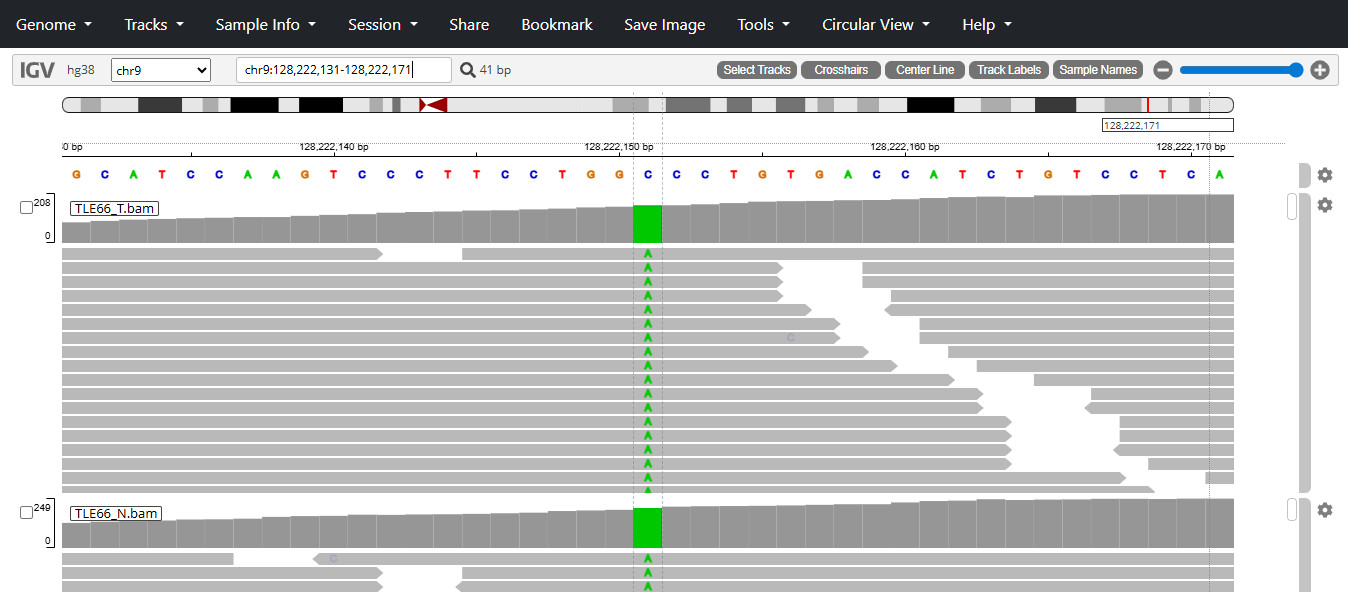

A good SNP is one that has high confidence (QUAL ≥ 30), is supported by enough sequencing reads (DP ≥ 20), and is based on reliably mapped reads (MQ ≥ 40).

In [41]:
echo -e "##fileformat=VCFv4.2\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\tSAMPLE1\tSAMPLE2" > diff_snps.vcf
awk -F'\t' '
$1 !~ /^#/ {
    split($10, s1, ":")
    split($11, s2, ":")
    gt1=s1[1]; gt2=s2[1]
    if(gt1 != gt2) 
        print $1"\t"$2"\t.\t"$4"\t"$5"\t.\tPASS\t.\tGT\t"gt1"\t"gt2
}' raw_snps.vcf >> diff_snps.vcf

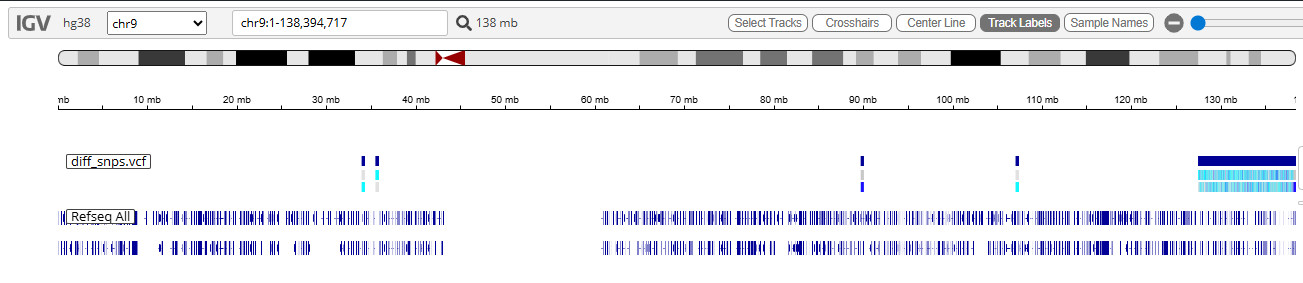

below is the snp from awk filtering.

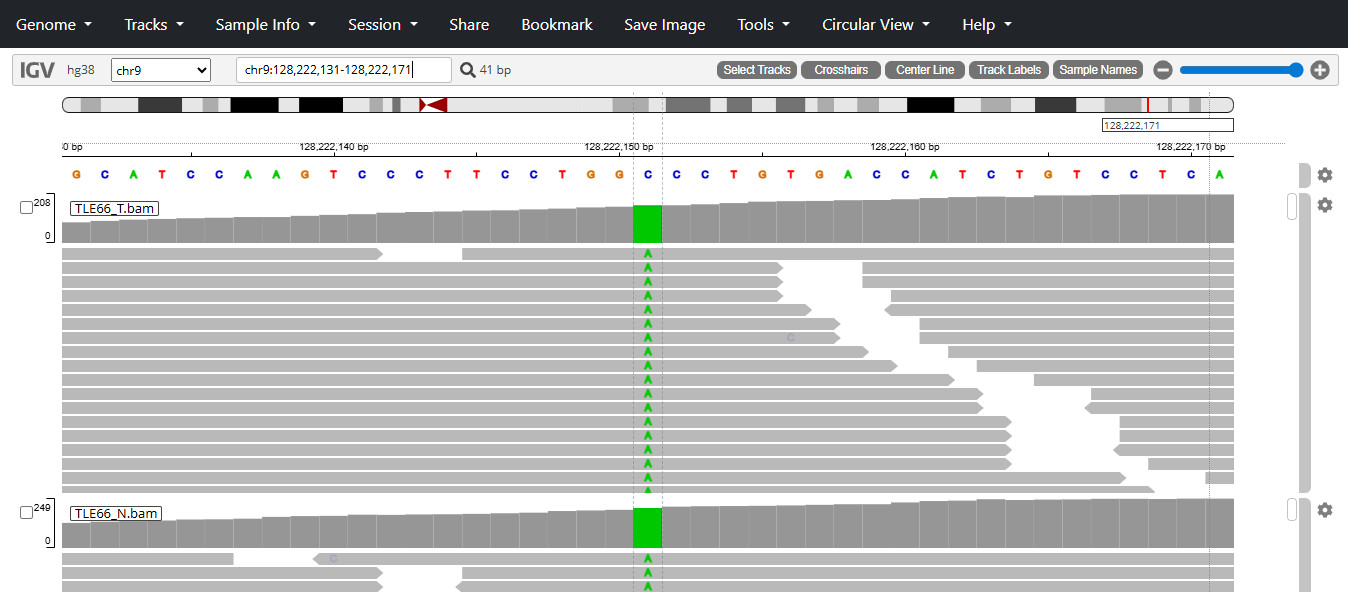

In [42]:
grep -v '#' raw_snps.vcf | head -2

chr9	34082802	.	C	T	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2
chr9	34082803	.	A	G	13.2571	.	DP=2;VDB=0.02;SGB=0.0985265;MQ0F=0;AC=2;AN=2;DP4=0,0,0,2;MQ=22	GT:PL:AD	./.:0,0,0:0,0	1/1:40,6,0:0,2


Not all SNPs are equaly convincing

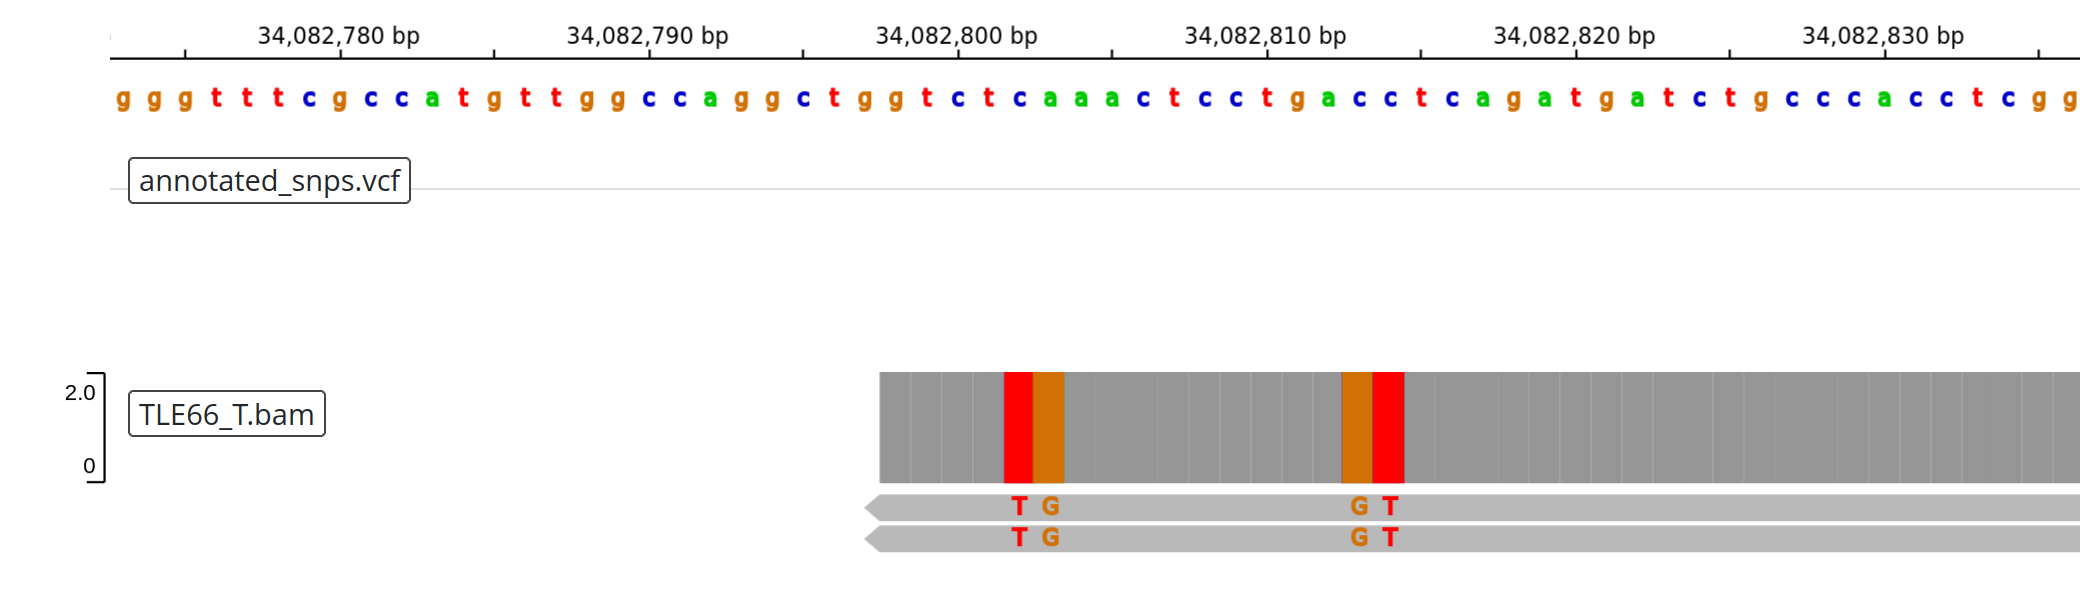

## SNP filtering & cleaning using `vt`

This is a VCF preprocessing pipeline that cleans up raw SNP calls before any downstream analysis. Each step fixes a specific class of problem:

* `vt decompose` splits multi-allelic variants (where multiple alternate alleles are listed on a single line) into separate biallelic records. Most tools downstream expect one variant per line, and PRS methods in particular are built around biallelic SNPs.
* `vt normalize -n -r $DB` left-aligns and normalizes indels against the reference genome. The same variant can be represented in multiple valid ways in VCF format — normalization ensures you have one canonical representation, which is critical when matching variants across datasets (e.g., GWAS summary statistics vs. your genotype calls).
* `vt uniq` removes exact duplicate records that may have arisen after decomposition and normalization — two originally different representations that are now identical.
* `vt view -f "QUAL>20"` filters out low-confidence variant calls. QUAL<20 corresponds roughly to less than 99% confidence that the variant is real, so you're dropping the noisiest calls.


In [43]:
cat raw_snps.vcf \
    | vt decompose - \
    | vt normalize -n -r $DB - \
    | vt uniq - \
    | vt view -f "QUAL>20" -h - \
    > clean_snps.vcf

decompose v0.5

options:     input VCF file        -
         [s] smart decomposition   false (experimental)
         [o] output VCF file       -

normalize vuniq v0.50.57



options:     input VCF file        options:     input VCF file                                  --

         [o] output VCF file                [o] output VCF file                                 --

         [w] sorting window size                             10000
         [n] no fail on reference inconsistency for non SNPs true
         [q] quiet                                           false
         [d] debug                                           false
         [r] reference FASTA file                            /staging/leuven/stg_00079/teaching/hg38_9/chr9.fa


stats: no. variants                 : 6661
       no. biallelic variants       : 6659
       no. multiallelic variants    : 2

       no. additional biallelics    : 2
       total no. of biallelics      : 6663

Time elapsed: 0.02s


stats: biall


<div style="background-color: khaki; padding: 10px;">

## Quality control

* Did all tools finish without error?
* Is the file structure correct? (no lines, start, end, header, etc)
* Find a high quality SNP (awk, sort, excel, whatever you like). Discuss the criteria.
* Attempt to find a variants that are different between the two samples (awk?). Check in IGV, copy/paste screenshot.
* Visualize the above SNP in IGV, copy/paste a screenshot.

</div>



Yes, the tools finished successfully.

In [44]:
# Check the total lines and variant lines
wc -l clean_snps.vcf
grep -v '^#' clean_snps.vcf | wc -l

3530 clean_snps.vcf
3499


In [45]:
grep -v '^#' clean_snps.vcf | sort -k6,6nr | head -n 1

chr9	137102481	.	T	G	486.063	.	DP=471;VDB=0.557019;SGB=-1.38629;RPBZ=1.16838;MQBZ=-1.73258;MQSBZ=0.956502;BQBZ=1.66605;SCBZ=0.147431;MQ0F=0.0636943;AC=4;AN=4;DP4=0,1,243,226;MQ=21	GT:PL:AD	1/1:255,255,0:1,232	1/1:255,255,0:0,236


In [46]:
awk -F'\t' 'BEGIN {OFS="\t"} $1 !~ /^#/ && $10 != $11 {print $1, $2, $4, $5, $10, $11}' clean_snps.vcf | head -n 5

chr9	127578816	C	T	0/1:24,0,97:4,1	0/1:48,0,134:6,2
chr9	127578974	A	G	0/1:255,0,255:28,29	0/1:201,0,255:40,14
chr9	127579080	A	G	0/1:110,0,133:5,5	0/1:95,0,118:5,4
chr9	127663498	C	T	1/1:57,6,0:0,2	1/1:36,3,0:0,1
chr9	127674824	G	T	./.:0,0,0:0,0	0/1:55,0,30:1,2


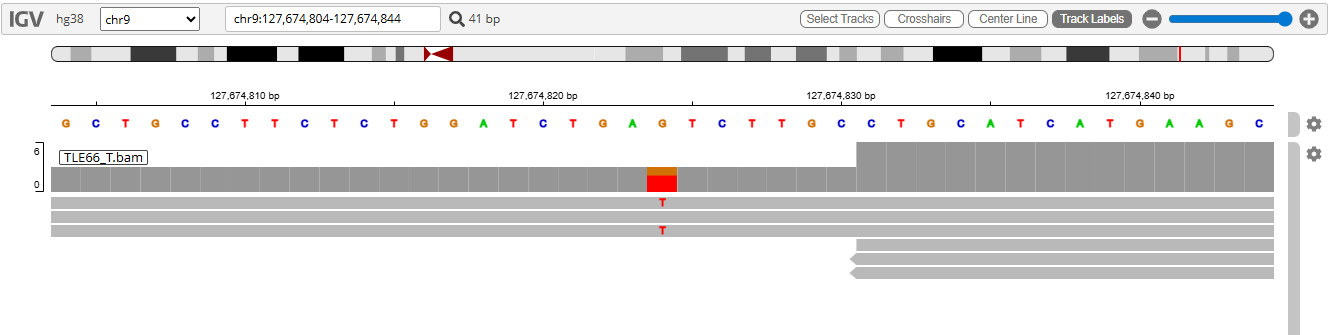

## Snp Annotation using SnpEff

In [47]:
# get help using:
snpEff || true

Error        :	Missing genomer_version parameter
Command line :	SnpEff  

snpEff version SnpEff 5.4a (build 2025-11-25 12:22), by Pablo Cingolani
Usage: snpEff [ann] [options] genome_version [input_file]


	variants_file                   : Default is STDIN



Options:
	-chr <string>                   : Prepend 'string' to chromosome name (e.g. 'chr1' instead of '1'). Only on TXT output.
	-classic                        : Use old style annotations instead of Sequence Ontology and Hgvs.
	-csvStats <file>                : Create CSV summary file.
	-download                       : Download reference genome if not available. Default: true
	-i <format>                     : Input format [ vcf, bed ]. Default: VCF.
	-fileList                       : Input actually contains a list of files to process.
	-o <format>                     : Output format [ vcf, gatk, bed, bedAnn ]. Default: VCF.
	-s , -stats, -htmlStats         : Create HTML summary file.  Default is 'snpEff_summary.html'
	-noSta



NEW VERSION!
	There is a new SnpEff version available: 
		Version      : 5.4C
		Release date : 2026-02-23
		Download URL : https://snpeff-public.s3.amazonaws.com/versions/snpEff_latest_core.zip



In [61]:
# sorry this is ugly - but to run snpEff - we need more memory
# I'm sure there is a more elegant way - but I could not find it..

SNPEFF_JAR="/lustre1/project/stg_00079/teaching/I0U19a_conda_2026/share/snpeff-5.4.0a-0/snpEff.jar"
#java -jar ${SNPEFF_JAR} download -dataDir /user/leuven/386/vsc38672/DATA/leuven_raw_data/omics/snpeff_database hg38

#tried to use hg38, it's more appropriate since the genome ref version is hg38
java -Xmx3400m -jar ${SNPEFF_JAR} eff hg38 -dataDir /user/leuven/386/vsc38672/DATA/leuven_raw_data/omics/snpeff_database \
        clean_snps.vcf > annotated_snps.vcf

#java -Xmx3400m -jar ${SNPEFF_JAR} eff hg19 -dataDir /staging/leuven/stg_00079/teaching/snpeff_db \
#        clean_snps.vcf > annotated_snps.vcf



NEW VERSION!
	There is a new SnpEff version available: 
		Version      : 5.4C
		Release date : 2026-02-23
		Download URL : https://snpeff-public.s3.amazonaws.com/versions/snpEff_latest_core.zip



<div style="background-color: khaki; padding: 10px;">

## snpEff Quality control

* Do you have annotations in the records? Show one HIGH impact one? 
* Can you think of other (simple) controls for a snpEff annotated vcf file?

</div>


In [62]:
grep -v '^#' annotated_snps.vcf | head -n 1

chr9	127578816	.	C	T	36.1174	.	DP=13;VDB=0.764235;SGB=-2.83311;RPBZ=-0.677989;MQBZ=0;BQBZ=0.173623;SCBZ=1.82574;MQ0F=0;AC=2;AN=4;DP4=10,0,3,0;MQ=60;ANN=T|intron_variant|MODIFIER|NIBAN2|NIBAN2|transcript|NM_001035534.3|protein_coding|1/13|c.16+106G>A||||||	GT:PL:AD	0/1:24,0,97:4,1	0/1:48,0,134:6,2


In [63]:
grep "HIGH" annotated_snps.vcf | head -n 1

chr9	128473042	.	A	G	485.901	.	DP=61;VDB=0.0115554;SGB=-1.38608;RPBZ=-0.994446;MQBZ=0;MQSBZ=0;BQBZ=-0.173231;SCBZ=0.129099;MQ0F=0;AC=4;AN=4;DP4=0,1,11,49;MQ=60;ANN=G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_001351577.1|protein_coding|7/20|c.959+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_153436.1|protein_coding|6/15|c.710+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_001242354.1|protein_coding|6/15|c.467+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_153432.1|protein_coding|6/15|c.842+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_153439.1|protein_coding|6/15|c.785+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_001242352.1|protein_coding|7/20|c.695+1A>G||||||,G|splice_donor_variant&intron_variant|HIGH|ODF2|ODF2|transcript|NM_001351578.1|protein_coding|7/20|c.959+1A>G||||||,G|splice_donor_variant&intron_var

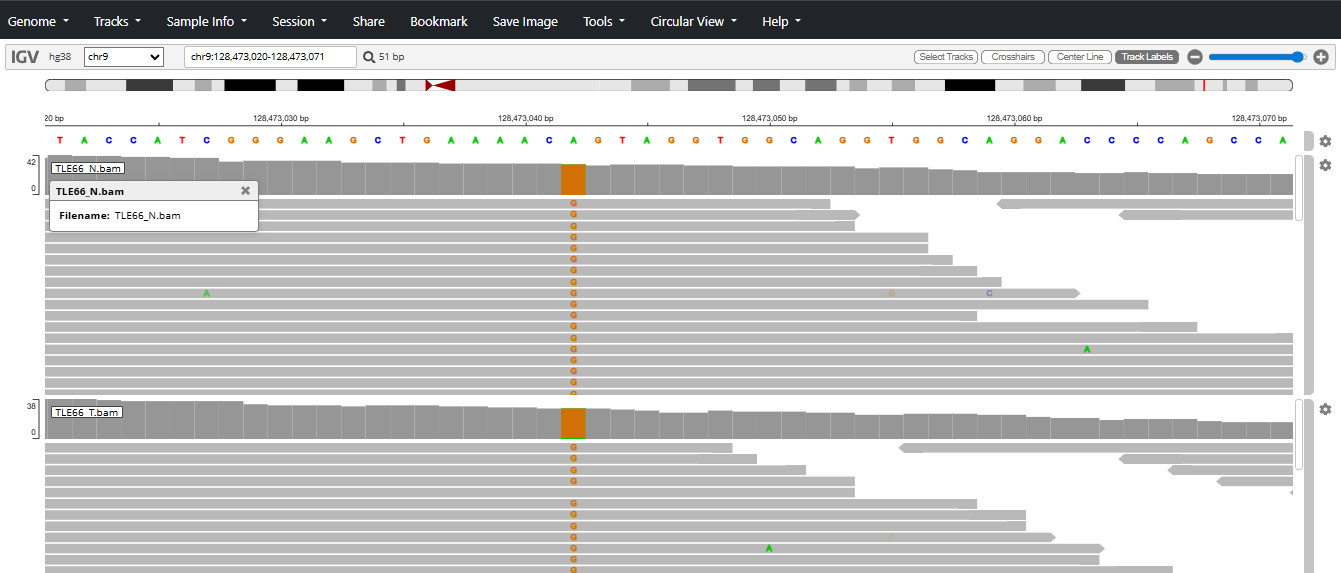

In [65]:
grep -v '^#' annotated_snps.vcf | grep -o 'ANN=[^;]*' | cut -d '|' -f 4 | sort | uniq -c | sort -nr | head

    134 VAV2
    106 COL5A1
     63 ADAMTSL2
     56 LOC401557-C9orf62
     53 RXRA-COL5A1
     50 TUBBP5
     48 RXRA
     47 MIR1268A
     44 EHMT1
     43 LAMC3


Check the HTML summary: snpEff generates an HTML report automatically. Take a look at the impact distribution—if literally 0% of your variants are showing up as "High" or "Moderate" impact, your gene model might be off.

Count the unique genes: Make sure you aren't just hitting a single gene over and over (which usually means you accidentally aligned to a very restricted region). You can quickly pull the top genes using this command:

Bash
grep -v '^#' annotated_snps.vcf | grep -o 'ANN=[^;]*' | cut -d '|' -f 4 | sort | uniq -c | sort -nr | head
Verify your line counts: A quick wc -l on your VCFs before and after running snpEff should show the exact same number of variant lines. snpEff just appends information; it shouldn't ever drop variants.

Watch out for reference mismatches: Grep your output VCF for WARNING_REF_DOES_NOT_MATCH_REFERENCE. If you see a ton of these, you likely used a different genome version for alignment.